In [18]:
!pip install statsbombpy mplsoccer --quiet

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid', font_scale=1.1)
COLORS = {'gol': '#e63946', 'no_gol': '#457b9d', 'neutral': '#2E4057'}

print('Librerias cargadas correctamente.')

Librerias cargadas correctamente.


In [20]:
from statsbombpy import sb

# Filtramos competiciones modernas
competitions = sb.competitions()
competiciones = competitions[
    (competitions['competition_id'].isin([11, 16, 43])) &
    (competitions['season_name'].apply(lambda x: int(x[:4]) >= 2003))
][['competition_id', 'competition_name', 'season_id', 'season_name']]

def cargar_disparos(competition_id, season_id, competition_name):
    try:
        matches = sb.matches(competition_id=competition_id, season_id=season_id)
        all_shots = []
        for match_id in matches['match_id']:
            events = sb.events(match_id=match_id)
            shots = events[events['type'] == 'Shot'].copy()
            if not shots.empty:
                shots['competition'] = competition_name
                shots['season_id']   = season_id
                shots['match_id']    = match_id
                all_shots.append(shots)
        if all_shots:
            return pd.concat(all_shots, ignore_index=True)
    except Exception as e:
        print(f'  Error: {e}')
    return pd.DataFrame()

print(f'Descargando {len(competiciones)} temporadas...\n')
all_shots_list = []
for _, row in competiciones.iterrows():
    print(f'  -> {row["competition_name"]} - {row["season_name"]}')
    shots_temp = cargar_disparos(row['competition_id'], row['season_id'], row['competition_name'])
    if not shots_temp.empty:
        all_shots_list.append(shots_temp)

df_raw = pd.concat(all_shots_list, ignore_index=True)

# Construimos dataset limpio
GOAL_X, GOAL_Y = 120, 40
GOAL_POST_Y1, GOAL_POST_Y2 = 36, 44

columnas = [
    'id', 'match_id', 'competition', 'season_id', 'minute', 'player',
    'team', 'location', 'shot_outcome', 'shot_type', 'shot_body_part',
    'shot_technique', 'shot_statsbomb_xg', 'under_pressure', 'shot_first_time'
]
columnas_ok = [c for c in columnas if c in df_raw.columns]
df = df_raw[columnas_ok].copy()
df['x'] = df['location'].apply(lambda loc: loc[0] if isinstance(loc, list) else np.nan)
df['y'] = df['location'].apply(lambda loc: loc[1] if isinstance(loc, list) else np.nan)
df.drop(columns=['location'], inplace=True)
df = df[df['shot_type'] != 'Penalty'].copy()
df['gol'] = (df['shot_outcome'] == 'Goal').astype(int)
df['shot_distance'] = np.sqrt((df['x'] - GOAL_X)**2 + (df['y'] - GOAL_Y)**2)

def calcular_angulo(x, y):
    a = np.array([x - GOAL_X, y - GOAL_POST_Y1])
    b = np.array([x - GOAL_X, y - GOAL_POST_Y2])
    cos_angle = np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-6)
    return np.degrees(np.arccos(np.clip(cos_angle, -1, 1)))

df['shot_angle'] = df.apply(lambda row: calcular_angulo(row['x'], row['y']), axis=1)
for col in ['shot_outcome', 'shot_type', 'shot_body_part', 'shot_technique']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()
for col in ['under_pressure', 'shot_first_time']:
    if col in df.columns:
        df[col] = df[col].fillna(False).astype(int)

print(f'\nDataset listo: {len(df):,} disparos, {df["gol"].sum():,} goles ({df["gol"].mean()*100:.1f}%)')

Descargando 33 temporadas...

  -> Champions League - 2018/2019
  -> Champions League - 2017/2018
  -> Champions League - 2016/2017
  -> Champions League - 2015/2016
  -> Champions League - 2014/2015
  -> Champions League - 2013/2014
  -> Champions League - 2012/2013
  -> Champions League - 2011/2012
  -> Champions League - 2010/2011
  -> Champions League - 2009/2010
  -> Champions League - 2008/2009
  -> Champions League - 2006/2007
  -> Champions League - 2004/2005
  -> Champions League - 2003/2004
  -> FIFA World Cup - 2022
  -> FIFA World Cup - 2018
  -> La Liga - 2020/2021
  -> La Liga - 2019/2020
  -> La Liga - 2018/2019
  -> La Liga - 2017/2018
  -> La Liga - 2016/2017
  -> La Liga - 2015/2016
  -> La Liga - 2014/2015
  -> La Liga - 2013/2014
  -> La Liga - 2012/2013
  -> La Liga - 2011/2012
  -> La Liga - 2010/2011
  -> La Liga - 2009/2010
  -> La Liga - 2008/2009
  -> La Liga - 2007/2008
  -> La Liga - 2006/2007
  -> La Liga - 2005/2006
  -> La Liga - 2004/2005

Dataset listo:

In [21]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/TFM_xG', exist_ok=True)

df.to_csv('/content/drive/MyDrive/TFM_xG/dataset_disparos_limpio.csv', index=False)
print('Dataset guardado en Google Drive correctamente.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset guardado en Google Drive correctamente.


In [22]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/TFM_xG/dataset_disparos_limpio.csv')

print(f'Dataset cargado correctamente.')
print(f'   Filas:    {len(df):,}')
print(f'   Columnas: {df.shape[1]}')
print(f'   Goles:    {df["gol"].sum():,} ({df["gol"].mean()*100:.1f}%)')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset cargado correctamente.
   Filas:    24,399
   Columnas: 19
   Goles:    2,788 (11.4%)


,id,match_id,competition,season_id,minute,player,team,shot_outcome,shot_type,shot_body_part,shot_technique,shot_statsbomb_xg,under_pressure,shot_first_time,x,y,gol,shot_distance,shot_angle
0,67b9cbde-0eb7-4800-9bfe-c2ce1ad406a6,22912,Champions League,4,9,Moussa Sissoko,Tottenham Hotspur,Off T,Open Play,Right Foot,Normal,0.026189,1,0,91.9,43.1,0,28.270479,16.014551
1,08c3746b-a125-4adb-991e-c8053578451a,22912,Champions League,4,16,Trent Alexander-Arnold,Liverpool,Off T,Open Play,Right Foot,Normal,0.006203,0,0,90.2,59.3,0,35.503943,10.844114
2,8fb3106d-10fb-42c6-bcf6-2ea34c7ff9a3,22912,Champions League,4,20,Mohamed Salah,Liverpool,Blocked,Open Play,Left Foot,Normal,0.039799,0,0,95.2,47.2,0,25.824020,16.952170
3,4004264d-14a1-4e0d-b01d-a5d025e26c17,22912,Champions League,4,21,Mohamed Salah,Liverpool,Wayward,Open Play,Left Foot,Normal,0.007078,0,0,113.0,59.5,0,20.718349,7.717212
4,ac439699-4dde-42dd-9f67-dd9ef6b6e885,22912,Champions League,4,37,Andrew Robertson,Liverpool,Saved,Open Play,Left Foot,Normal,0.009163,0,0,98.4,20.4,0,29.167105,11.695906


El conjunto de datos ya preparado se encuentra en Google Drive y se carga directamente desde allí en el Notebook 01, así no es necesario descargarlo otra vez desde StatsBomb. Se verifica que tiene 24.399 filas y 19 columnas, con una proporción de goles del 11.4%.

In [23]:
print('Tipos de variables en el dataset:')
print(df.dtypes.to_string())
print(f'\nValores unicos por variable categorica:')
for col in ['shot_body_part', 'shot_technique', 'shot_type', 'competition']:
    if col in df.columns:
        print(f'  {col}: {df[col].unique()}')

Tipos de variables en el dataset:
id                    object
match_id               int64
competition           object
season_id              int64
minute                 int64
player                object
team                  object
shot_outcome          object
shot_type             object
shot_body_part        object
shot_technique        object
shot_statsbomb_xg    float64
under_pressure         int64
shot_first_time        int64
x                    float64
y                    float64
gol                    int64
shot_distance        float64
shot_angle           float64

Valores unicos por variable categorica:
  shot_body_part: ['Right Foot' 'Left Foot' 'Head' 'Other']
  shot_technique: ['Normal' 'Volley' 'Half Volley' 'Lob' 'Overhead Kick' 'Diving Header'
 'Backheel']
  shot_type: ['Open Play' 'Free Kick' 'Corner']
  competition: ['Champions League' 'FIFA World Cup' 'La Liga']


Primero se verifican los tipos de cada variable antes de hacer cualquier cambio. Las variables numéricas están correctamente en formato float64 o int64, y las categóricas en formato object. Se identifican 4 categorías en shot_body_part, 7 en shot_technique y 3 competiciones, lo que determina la estrategia de encoding aplicada en el siguiente paso.

In [24]:

categoricas = ['shot_body_part', 'shot_technique']
categoricas = [c for c in categoricas if c in df.columns]

df_encoded = pd.get_dummies(df, columns=categoricas, drop_first=True, dtype=int)

le = LabelEncoder()
df_encoded['competition_code'] = le.fit_transform(df['competition'])
print('Categorias de competition_code:')
for i, cat in enumerate(le.classes_):
    print(f'  {i} = {cat}')

nuevas_cols = [c for c in df_encoded.columns if c not in df.columns]
print(f'\nNuevas columnas creadas por encoding: {len(nuevas_cols)}')
print(nuevas_cols)
print(f'\nTotal columnas tras encoding: {df_encoded.shape[1]}')

Categorias de competition_code:
  0 = Champions League
  1 = FIFA World Cup
  2 = La Liga

Nuevas columnas creadas por encoding: 10
['shot_body_part_Left Foot', 'shot_body_part_Other', 'shot_body_part_Right Foot', 'shot_technique_Diving Header', 'shot_technique_Half Volley', 'shot_technique_Lob', 'shot_technique_Normal', 'shot_technique_Overhead Kick', 'shot_technique_Volley', 'competition_code']

Total columnas tras encoding: 27


Se utiliza un método llamado One-Hot Encoding en las columnas shot_body_part y shot_technique, eliminando la primera opción de cada una para evitar que las variables estén demasiado relacionadas entre sí. Como resultado, el conjunto de datos pasa de tener 19 columnas a tener 27, ya que se crean 10 nuevas variables dummy.

In [28]:
# Carga local de los archivos de Transfermarkt
# ya subidos manualmente a Colab
# Licencia: CC0-1.0 — dominio publico, sin restricciones de uso
# Fuente: kaggle.com/datasets/davidcariboo/player-scores

try:
    players = pd.read_csv('players.csv')
    valuations = pd.read_csv('player_valuations.csv')
    print(f'Jugadores:    {len(players):,} filas, {players.shape[1]} columnas')
    print(f'Valoraciones: {len(valuations):,} filas, {valuations.shape[1]} columnas')
    print(f'\nColumnas jugadores: {list(players.columns)}')
    print(f'Columnas valoraciones: {list(valuations.columns)}')
    transfermarkt_ok = True
except Exception as e:
    print(f'Error: {e}')
    transfermarkt_ok = False

Jugadores:    50,149 filas, 26 columnas
Valoraciones: 656,301 filas, 6 columnas

Columnas jugadores: ['player_id', 'first_name', 'last_name', 'name', 'last_season', 'current_club_id', 'player_code', 'country_of_birth', 'city_of_birth', 'country_of_citizenship', 'date_of_birth', 'sub_position', 'position', 'foot', 'height_in_cm', 'contract_expiration_date', 'agent_name', 'image_url', 'international_caps', 'international_goals', 'current_national_team_id', 'url', 'current_club_domestic_competition_id', 'current_club_name', 'market_value_in_eur', 'highest_market_value_in_eur']
Columnas valoraciones: ['player_id', 'date', 'market_value_in_eur', 'current_club_name', 'current_club_id', 'player_club_domestic_competition_id']


En esta parte, se cargan dos archivos de Transfermarkt (players.csv y player_valuations.csv) que previamente se subieron manualmente a Colab. Al final, se confirma que ambos archivos se han cargado correctamente: en el primero hay información de 50.149 jugadores con 26 datos diferentes sobre cada uno, y en el segundo hay más de 656.000 registros con los valores de mercado de los jugadores en diferentes momentos. Estos datos luego se cruzarán con los resultados del modelo xG.

In [29]:
if transfermarkt_ok:
    valoracion_reciente = (
        valuations
        .sort_values('date', ascending=False)
        .groupby('player_id')
        .first()
        .reset_index()[['player_id', 'market_value_in_eur']]
    )


    players_valor = players[['player_id','name']].merge(
        valoracion_reciente, on='player_id', how='inner'
    )
    players_valor.columns = ['player_id', 'player_name', 'market_value_eur']
    players_valor['market_value_M'] = players_valor['market_value_eur'] / 1_000_000

    print(f'Jugadores con valoracion disponible: {len(players_valor):,}')
    print(f'\nEstadisticas de valor de mercado (millones EUR):')
    print(players_valor['market_value_M'].describe().round(2).to_string())

    # Calcular xG acumulado por jugador en dataset
    xg_jugador = (
        df_encoded
        .groupby('player')
        .agg(
            n_disparos=('gol', 'count'),
            goles_reales=('gol', 'sum'),
            xg_acumulado=('shot_statsbomb_xg', 'sum'),
            xg_por_disparo=('shot_statsbomb_xg', 'mean')
        )
        .reset_index()
    )
    xg_jugador.columns = ['player_name','n_disparos','goles_reales',
                          'xg_acumulado','xg_por_disparo']

    # Filtrar jugadores con suficientes disparos para que el analisis sea robusto
    xg_jugador = xg_jugador[xg_jugador['n_disparos'] >= 20].copy()

    # Cruce entre xG y valor de mercado
    df_negocio = xg_jugador.merge(players_valor, on='player_name', how='inner')
    df_negocio['eficiencia'] = df_negocio['goles_reales'] / df_negocio['xg_acumulado']

    print(f'\nJugadores con xG y valoracion disponibles: {len(df_negocio):,}')
    print('\nTop 10 jugadores por xG acumulado:')
    print(df_negocio.nlargest(10, 'xg_acumulado')[
        ['player_name','n_disparos','goles_reales','xg_acumulado','market_value_M']
    ].to_string(index=False))

    ruta = '/content/drive/MyDrive/TFM_xG/'
df_negocio.to_csv(ruta + 'dataset_xg_transfermarkt.csv', index=False)
print(f'\nDataset guardado en Drive como {ruta}dataset_xg_transfermarkt.csv')


Jugadores con valoracion disponible: 41,528

Estadisticas de valor de mercado (millones EUR):
count    41528.00
mean         1.51
std          5.85
min          0.01
25%          0.10
50%          0.28
75%          0.70
max        200.00

Jugadores con xG y valoracion disponibles: 39

Top 10 jugadores por xG acumulado:
       player_name  n_disparos  goles_reales  xg_acumulado  market_value_M
 Antoine Griezmann         255            42     36.474054             8.0
     Karim Benzema         157            31     25.202437             5.0
Zlatan Ibrahimović          82            13     10.531066             2.0
   Ousmane Dembélé         112            16     10.067850           100.0
    Cédric Bakambu          52            13      9.716121             1.2
     Ludovic Giuly          37             6      6.513558             0.4
     John Guidetti          34             7      5.575811             0.6
   Frenkie de Jong          20             4      5.553983            35.0
    

Se cruzan los datos de xG acumulado por jugador con su valoración de mercado más reciente. Tras filtrar jugadores con al menos 20 disparos, se obtienen 39 jugadores con ambas fuentes disponibles. El resultado lo guardamos para su uso en la Sección 7 de interpretabilidad y negocio.

In [30]:
# Definimos las variables predictoras y la variable objetivo
# Se excluyen variables de identificacion (id, match_id, player, team)
# y variables que causarian data leakage (shot_outcome, shot_statsbomb_xg)

# Variables predictoras del modelo xG
features_base = [
    'shot_distance',
    'shot_angle',
    'under_pressure',
    'shot_first_time',
    'minute',
]

# Añadir columnas de dummies generadas por encoding
dummies_cols = [c for c in df_encoded.columns
                if c.startswith('shot_body_part_') or c.startswith('shot_technique_')]
features = features_base + dummies_cols
features = [f for f in features if f in df_encoded.columns]

TARGET = 'gol'

print(f'Variable objetivo: {TARGET}')
print(f'Variables predictoras ({len(features)}):')
for f in features:
    print(f'  - {f}')

Variable objetivo: gol
Variables predictoras (14):
  - shot_distance
  - shot_angle
  - under_pressure
  - shot_first_time
  - minute
  - shot_body_part_Left Foot
  - shot_body_part_Other
  - shot_body_part_Right Foot
  - shot_technique_Diving Header
  - shot_technique_Half Volley
  - shot_technique_Lob
  - shot_technique_Normal
  - shot_technique_Overhead Kick
  - shot_technique_Volley


Se definen las 14 variables predictoras del modelo xG: las 5 variables base (distancia, ángulo, presión, disparo a la primera y minuto) más las 9 variables dummy generadas en el paso anterior. Se excluyen variables de identificación y shot_statsbomb_xg para evitar data leakage.

In [31]:
# Particion estratificada: 70% train, 15% validacion, 15% test
# La estratificacion garantiza que la proporcion de goles es igual


X = df_encoded[features]
y = df_encoded[TARGET]

# Primera division: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Segunda division: 50% validacion, 50% test (del 30% restante -> 15% cada uno)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print('Particion del dataset:')
print(f'  Train:      {len(X_train):,} disparos ({len(X_train)/len(X)*100:.1f}%)')
print(f'  Validacion: {len(X_val):,} disparos ({len(X_val)/len(X)*100:.1f}%)')
print(f'  Test:       {len(X_test):,} disparos ({len(X_test)/len(X)*100:.1f}%)')
print(f'\nProporcion de goles por conjunto (verificacion estratificacion):')
print(f'  Train:      {y_train.mean()*100:.2f}%')
print(f'  Validacion: {y_val.mean()*100:.2f}%')
print(f'  Test:       {y_test.mean()*100:.2f}%')

Particion del dataset:
  Train:      17,079 disparos (70.0%)
  Validacion: 3,660 disparos (15.0%)
  Test:       3,660 disparos (15.0%)

Proporcion de goles por conjunto (verificacion estratificacion):
  Train:      11.43%
  Validacion: 11.42%
  Test:       11.42%


El dataset se divide en tres conjuntos de forma estratificada: 70% para entrenamiento (17.079 disparos), 15% para validación (3.660) y 15% para test (3.660). La estratificación garantiza que la proporción de goles se mantiene constante en los tres conjuntos — aproximadamente 11.4% en todos ellos — lo que es esencial cuando el dataset está desbalanceado.

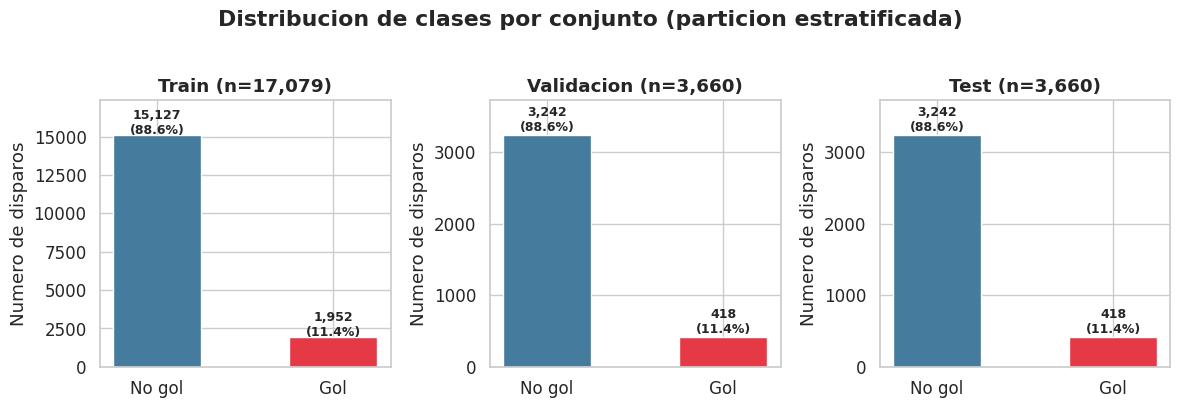

In [32]:
# Grafico de verificacion de la particion estratificada
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
conjuntos = [
    ('Train', y_train),
    ('Validacion', y_val),
    ('Test', y_test)
]

for i, (nombre, y_conj) in enumerate(conjuntos):
    conteo = y_conj.value_counts()
    axes[i].bar(['No gol','Gol'], [conteo[0], conteo[1]],
                color=[COLORS['no_gol'], COLORS['gol']],
                edgecolor='white', width=0.5)
    axes[i].set_title(f'{nombre} (n={len(y_conj):,})', fontweight='bold')
    axes[i].set_ylabel('Numero de disparos')
    axes[i].set_ylim(0, max(conteo[0], conteo[1]) * 1.15)
    for j, (val, pct) in enumerate(zip([conteo[0],conteo[1]],
                                        [y_conj.mean()*100, (1-y_conj.mean())*100])):
        axes[i].text(j, val + 50, f'{val:,}\n({y_conj.value_counts(normalize=True)[j]*100:.1f}%)',
                     ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Distribucion de clases por conjunto (particion estratificada)',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('particion_train_val_test.png', dpi=150, bbox_inches='tight')
plt.show()

El gráfico confirma visualmente que la partición estratificada funciona correctamente. Los tres conjuntos mantienen exactamente la misma proporción de goles (11.4%) y no goles (88.6%), lo que garantiza que los modelos se entrenan y evalúan en condiciones comparables.

In [33]:
import pickle


X_train.to_csv('X_train.csv', index=False)
X_val.to_csv('X_val.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_val.to_csv('y_val.csv', index=False)
y_test.to_csv('y_test.csv', index=False)


with open('features.pkl', 'wb') as f:
    pickle.dump(features, f)

print('Datasets guardados correctamente:')
print(f'  X_train: {X_train.shape}  ->  X_train.csv')
print(f'  X_val:   {X_val.shape}    ->  X_val.csv')
print(f'  X_test:  {X_test.shape}   ->  X_test.csv')
print(f'  y_train, y_val, y_test    ->  CSVs correspondientes')
print(f'  Lista de features         ->  features.pkl')
print('\nListos para el notebook 03_modelizacion.ipynb')

Datasets guardados correctamente:
  X_train: (17079, 14)  ->  X_train.csv
  X_val:   (3660, 14)    ->  X_val.csv
  X_test:  (3660, 14)   ->  X_test.csv
  y_train, y_val, y_test    ->  CSVs correspondientes
  Lista de features         ->  features.pkl

Listos para el notebook 03_modelizacion.ipynb


Los seis conjuntos resultantes (X_train, X_val, X_test, y_train, y_val, y_test) se guardan en formato CSV junto con la lista de variables predictoras en formato pickle. Todos los archivos quedan listos para ser cargados directamente en el notebook de modelización sin necesidad de repetir el proceso de transformación.

In [34]:
from google.colab import drive
drive.mount('/content/drive')
import os
os.makedirs('/content/drive/MyDrive/TFM_xG/', exist_ok=True)

X_train.to_csv('/content/drive/MyDrive/TFM_xG/X_train.csv', index=False)
X_val.to_csv('/content/drive/MyDrive/TFM_xG/X_val.csv', index=False)
X_test.to_csv('/content/drive/MyDrive/TFM_xG/X_test.csv', index=False)
y_train.to_csv('/content/drive/MyDrive/TFM_xG/y_train.csv', index=False)
y_val.to_csv('/content/drive/MyDrive/TFM_xG/y_val.csv', index=False)
y_test.to_csv('/content/drive/MyDrive/TFM_xG/y_test.csv', index=False)

import pickle
with open('/content/drive/MyDrive/TFM_xG/features.pkl', 'wb') as f:
    pickle.dump(features, f)

print('Todos los archivos guardados en Google Drive correctamente.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Todos los archivos guardados en Google Drive correctamente.


In [35]:
ruta = '/content/drive/MyDrive/TFM/'

X_train.to_csv(ruta + 'X_train.csv', index=False)
X_val.to_csv(ruta + 'X_val.csv', index=False)
X_test.to_csv(ruta + 'X_test.csv', index=False)
y_train.to_csv(ruta + 'y_train.csv', index=False)
y_val.to_csv(ruta + 'y_val.csv', index=False)
y_test.to_csv(ruta + 'y_test.csv', index=False)

import pickle
with open(ruta + 'features.pkl', 'wb') as f:
    pickle.dump(features, f)

print('Todos los archivos guardados en Drive.')

Todos los archivos guardados en Drive.
